In [1]:
import torch

# 创建一个 2x3 的全 0 张量
a = torch.zeros(2, 3)
print(a)

# 创建一个 2x3 的全 1 张量
b = torch.ones(2, 3)
print(b)

# 创建一个 2x3 的随机数张量
c = torch.randn(2, 3)
print(c)

# 从 NumPy 数组创建张量
import numpy as np
numpy_array = np.array([[1, 2], [3, 4]])
tensor_from_numpy = torch.from_numpy(numpy_array)
print(tensor_from_numpy)

# 在指定设备（CPU/GPU）上创建张量
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
d = torch.randn(2, 3, device=device)
print(d)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[-1.2417,  0.2925, -1.8279],
        [ 1.8575, -1.7317,  0.7597]])
tensor([[1, 2],
        [3, 4]], dtype=torch.int32)
tensor([[ 0.2563, -0.2982,  0.1293],
        [ 1.2308, -1.3106,  0.4287]], device='cuda:0')


In [2]:
# 创建一个需要计算梯度的张量
x = torch.randn(2, 2, requires_grad=True)
print(x)

# 执行某些操作
y = x + 2
z = y * y * 3
out = z.mean()

print(out)

tensor([[-0.7493,  0.5320],
        [ 1.0024, -0.3754]], requires_grad=True)
tensor(14.7217, grad_fn=<MeanBackward0>)


In [3]:
import torch.nn as nn
import torch.optim as optim

# 定义一个简单的全连接神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

# 创建网络实例
model = SimpleNN()

# 打印模型结构
print(model)

SimpleNN(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 定义一个简单的神经网络模型
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

# 2. 创建模型实例
model = SimpleNN()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

# 4. 假设我们有训练数据 X 和 Y
X = torch.randn(10, 2)  # 10 个样本，2 个特征
Y = torch.randn(10, 1)  # 10 个目标值

# 5. 训练循环
for epoch in range(100):  # 训练 100 轮
    optimizer.zero_grad()  # 清空之前的梯度
    output = model(X)  # 前向传播
    loss = criterion(output, Y)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新参数
    
    # 每 10 轮输出一次损失
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 1.0683
Epoch [20/100], Loss: 1.0413
Epoch [30/100], Loss: 1.0176
Epoch [40/100], Loss: 0.9965
Epoch [50/100], Loss: 0.9780
Epoch [60/100], Loss: 0.9619
Epoch [70/100], Loss: 0.9478
Epoch [80/100], Loss: 0.9355
Epoch [90/100], Loss: 0.9248
Epoch [100/100], Loss: 0.9155


In [5]:
import torch

tensor = torch.tensor([1, 2, 3])
print(tensor)

tensor([1, 2, 3])


In [6]:
import numpy as np

np_array = np.array([1, 2, 3])
tensor = torch.from_numpy(np_array)
print(tensor)

tensor([1, 2, 3], dtype=torch.int32)


In [7]:
import torch

tensor_2d = torch.tensor([
    [-9, 4, 2, 5, 7],
    [3, 0, 12, 8, 6],
    [1, 23, -6, 45, 2],
    [22, 3, -1, 72, 6]
])
print("2D Tensor (Matrix):\n", tensor_2d)
print("Shape:", tensor_2d.shape)  # 形状

2D Tensor (Matrix):
 tensor([[-9,  4,  2,  5,  7],
        [ 3,  0, 12,  8,  6],
        [ 1, 23, -6, 45,  2],
        [22,  3, -1, 72,  6]])
Shape: torch.Size([4, 5])


In [8]:
# 导入PyTorch库
import torch
import torch.nn as nn

# 定义输入层大小、隐藏层大小、输出层大小和批量大小
n_in, n_h, n_out, batch_size = 10, 5, 1, 10

# 创建虚拟输入数据和目标数据
x = torch.randn(batch_size, n_in)  # 随机生成输入数据
y = torch.tensor([[1.0], [0.0], [0.0], 
                 [1.0], [1.0], [1.0], [0.0], [0.0], [1.0], [1.0]])  # 目标输出数据

# 创建顺序模型，包含线性层、ReLU激活函数和Sigmoid激活函数
model = nn.Sequential(
   nn.Linear(n_in, n_h),  # 输入层到隐藏层的线性变换
   nn.ReLU(),            # 隐藏层的ReLU激活函数
   nn.Linear(n_h, n_out),  # 隐藏层到输出层的线性变换
   nn.Sigmoid()           # 输出层的Sigmoid激活函数
)

# 定义均方误差损失函数和随机梯度下降优化器
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 学习率为0.01

# 执行梯度下降算法进行模型训练
for epoch in range(50):  # 迭代50次
   y_pred = model(x)  # 前向传播，计算预测值
   loss = criterion(y_pred, y)  # 计算损失
   print('epoch: ', epoch, 'loss: ', loss.item())  # 打印损失值

   optimizer.zero_grad()  # 清零梯度
   loss.backward()  # 反向传播，计算梯度
   optimizer.step()  # 更新模型参数

epoch:  0 loss:  0.2981361746788025
epoch:  1 loss:  0.2977105379104614
epoch:  2 loss:  0.29728564620018005
epoch:  3 loss:  0.2968616187572479
epoch:  4 loss:  0.2964383363723755
epoch:  5 loss:  0.29601582884788513
epoch:  6 loss:  0.29559415578842163
epoch:  7 loss:  0.295173317193985
epoch:  8 loss:  0.2947532534599304
epoch:  9 loss:  0.29433393478393555
epoch:  10 loss:  0.2939154803752899
epoch:  11 loss:  0.29349780082702637
epoch:  12 loss:  0.2930809259414673
epoch:  13 loss:  0.2926648259162903
epoch:  14 loss:  0.29224956035614014
epoch:  15 loss:  0.29183512926101685
epoch:  16 loss:  0.29142147302627563
epoch:  17 loss:  0.2910086214542389
epoch:  18 loss:  0.290596604347229
epoch:  19 loss:  0.2901853322982788
epoch:  20 loss:  0.28977495431900024
epoch:  21 loss:  0.289365291595459
epoch:  22 loss:  0.2889564633369446
epoch:  23 loss:  0.28854846954345703
epoch:  24 loss:  0.28814131021499634
epoch:  25 loss:  0.28773489594459534
epoch:  26 loss:  0.2873292565345764
ep

Epoch [1/50], Loss: 0.2124
Epoch [2/50], Loss: 0.2122
Epoch [3/50], Loss: 0.2121
Epoch [4/50], Loss: 0.2119
Epoch [5/50], Loss: 0.2117
Epoch [6/50], Loss: 0.2116
Epoch [7/50], Loss: 0.2114
Epoch [8/50], Loss: 0.2112
Epoch [9/50], Loss: 0.2110
Epoch [10/50], Loss: 0.2109
Epoch [11/50], Loss: 0.2107
Epoch [12/50], Loss: 0.2105
Epoch [13/50], Loss: 0.2104
Epoch [14/50], Loss: 0.2102
Epoch [15/50], Loss: 0.2100
Epoch [16/50], Loss: 0.2099
Epoch [17/50], Loss: 0.2097
Epoch [18/50], Loss: 0.2095
Epoch [19/50], Loss: 0.2094
Epoch [20/50], Loss: 0.2092
Epoch [21/50], Loss: 0.2090
Epoch [22/50], Loss: 0.2089
Epoch [23/50], Loss: 0.2087
Epoch [24/50], Loss: 0.2085
Epoch [25/50], Loss: 0.2084
Epoch [26/50], Loss: 0.2082
Epoch [27/50], Loss: 0.2080
Epoch [28/50], Loss: 0.2079
Epoch [29/50], Loss: 0.2077
Epoch [30/50], Loss: 0.2076
Epoch [31/50], Loss: 0.2074
Epoch [32/50], Loss: 0.2072
Epoch [33/50], Loss: 0.2071
Epoch [34/50], Loss: 0.2069
Epoch [35/50], Loss: 0.2067
Epoch [36/50], Loss: 0.2066
E

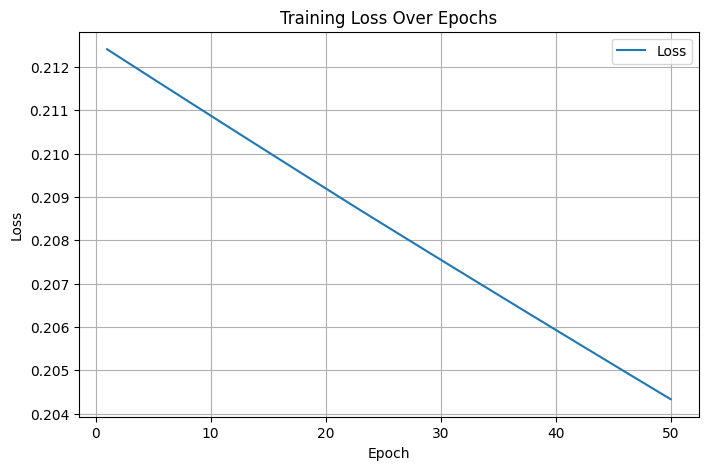

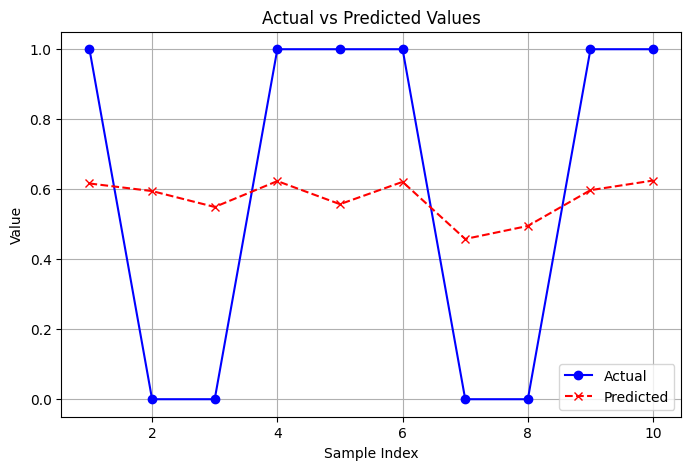

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 定义输入层大小、隐藏层大小、输出层大小和批量大小
n_in, n_h, n_out, batch_size = 10, 5, 1, 10

# 创建虚拟输入数据和目标数据
x = torch.randn(batch_size, n_in)  # 随机生成输入数据
y = torch.tensor([[1.0], [0.0], [0.0], 
                  [1.0], [1.0], [1.0], [0.0], [0.0], [1.0], [1.0]])  # 目标输出数据

# 创建顺序模型，包含线性层、ReLU激活函数和Sigmoid激活函数
model = nn.Sequential(
    nn.Linear(n_in, n_h),  # 输入层到隐藏层的线性变换
    nn.ReLU(),            # 隐藏层的ReLU激活函数
    nn.Linear(n_h, n_out),  # 隐藏层到输出层的线性变换
    nn.Sigmoid()           # 输出层的Sigmoid激活函数
)

# 定义均方误差损失函数和随机梯度下降优化器
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 学习率为0.01

# 用于存储每轮的损失值
losses = []

# 执行梯度下降算法进行模型训练
for epoch in range(50):  # 迭代50次
    y_pred = model(x)  # 前向传播，计算预测值
    loss = criterion(y_pred, y)  # 计算损失
    losses.append(loss.item())  # 记录损失值
    print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')  # 打印损失值

    optimizer.zero_grad()  # 清零梯度
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新模型参数

# 可视化损失变化曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# 可视化预测结果与实际目标值对比
y_pred_final = model(x).detach().numpy()  # 最终预测值
y_actual = y.numpy()  # 实际值

plt.figure(figsize=(8, 5))
plt.plot(range(1, batch_size + 1), y_actual, 'o-', label='Actual', color='blue')
plt.plot(range(1, batch_size + 1), y_pred_final, 'x--', label='Predicted', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

In [11]:
import matplotlib

print(matplotlib.__version__)

3.9.4


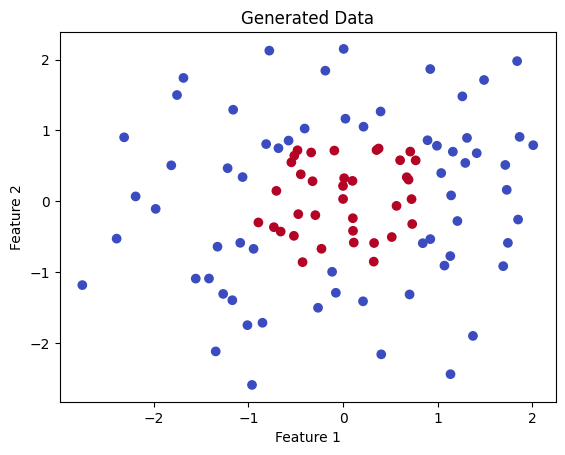

Epoch [10/100], Loss: 0.6633
Epoch [20/100], Loss: 0.6434
Epoch [30/100], Loss: 0.6304
Epoch [40/100], Loss: 0.6203
Epoch [50/100], Loss: 0.6121
Epoch [60/100], Loss: 0.6045
Epoch [70/100], Loss: 0.5969
Epoch [80/100], Loss: 0.5891
Epoch [90/100], Loss: 0.5817
Epoch [100/100], Loss: 0.5748


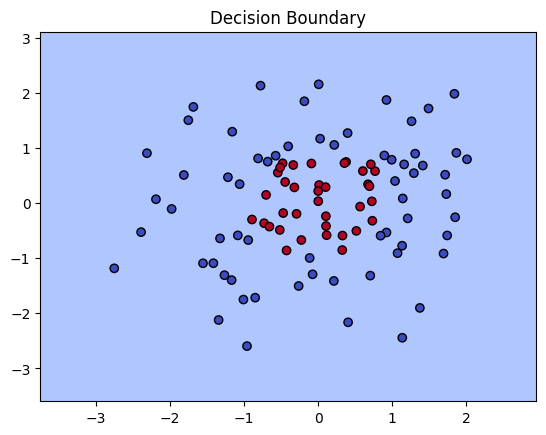

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 生成一些随机数据
n_samples = 100
data = torch.randn(n_samples, 2)  # 生成 100 个二维数据点
labels = (data[:, 0]**2 + data[:, 1]**2 < 1).float().unsqueeze(1)  # 点在圆内为1，圆外为0

# 可视化数据
plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm')
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 定义前馈神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 定义神经网络的层
        self.fc1 = nn.Linear(2, 4)  # 输入层有 2 个特征，隐藏层有 4 个神经元
        self.fc2 = nn.Linear(4, 1)  # 隐藏层输出到 1 个神经元（用于二分类）
        self.sigmoid = nn.Sigmoid()  # 二分类激活函数

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 激活函数
        x = self.sigmoid(self.fc2(x))  # 输出层使用 Sigmoid 激活函数
        return x

# 实例化模型
model = SimpleNN()

# 定义损失函数和优化器
criterion = nn.BCELoss()  # 二元交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 使用随机梯度下降优化器

# 训练
epochs = 100
for epoch in range(epochs):
    # 前向传播
    outputs = model(data)
    loss = criterion(outputs, labels)

    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 每 10 轮打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# 可视化决策边界
def plot_decision_boundary(model, data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, 0.1), torch.arange(y_min, y_max, 0.1), indexing='ij')
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    predictions = model(grid).detach().numpy().reshape(xx.shape)
    plt.contourf(xx, yy, predictions, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.7)
    plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm', edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, data)

In [2]:
import torch
from torch.utils.data import Dataset

# 自定义数据集类
class MyDataset(Dataset):
    def __init__(self, X_data, Y_data):
        """
        初始化数据集，X_data 和 Y_data 是两个列表或数组
        X_data: 输入特征
        Y_data: 目标标签
        """
        self.X_data = X_data
        self.Y_data = Y_data

    def __len__(self):
        """返回数据集的大小"""
        return len(self.X_data)

    def __getitem__(self, idx):
        """返回指定索引的数据"""
        x = torch.tensor(self.X_data[idx], dtype=torch.float32)  # 转换为 Tensor
        y = torch.tensor(self.Y_data[idx], dtype=torch.float32)
        return x, y

# 示例数据
X_data = [[1, 2], [3, 4], [5, 6], [7, 8]]  # 输入特征
Y_data = [1, 0, 1, 0]  # 目标标签

# 创建数据集实例
dataset = MyDataset(X_data, Y_data)
from torch.utils.data import DataLoader

# 创建 DataLoader 实例，batch_size 设置每次加载的样本数量
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 打印加载的数据
for epoch in range(1):
    for batch_idx, (inputs, labels) in enumerate(dataloader):
        print(f'Batch {batch_idx + 1}:')
        print(f'Inputs: {inputs}')
        print(f'Labels: {labels}')

Batch 1:
Inputs: tensor([[5., 6.],
        [1., 2.]])
Labels: tensor([1., 1.])
Batch 2:
Inputs: tensor([[3., 4.],
        [7., 8.]])
Labels: tensor([0., 0.])


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 随机种子，确保每次运行结果一致
torch.manual_seed(42)

# 生成训练数据
X = torch.randn(100, 2)  # 100 个样本，每个样本 2 个特征
true_w = torch.tensor([2.0, 3.0])  # 假设真实权重
true_b = 4.0  # 偏置项
Y = X @ true_w + true_b + torch.randn(100) * 0.1  # 加入一些噪声

# 打印部分数据
print(X[:5])
print(Y[:5])

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])
tensor([12.4460, -0.4663,  1.7666, -0.9357,  7.4781])


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 准备数据
torch.manual_seed(42)
X = torch.randn(100, 2)  # 100 个样本，2 个特征
true_w = torch.tensor([2.0, 3.0])
true_b = 4.0
Y = X @ true_w + true_b + torch.randn(100) * 0.1

# 2. 定义模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 4. 训练模型
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()

    predictions = model(X)
    loss = criterion(predictions.squeeze(), Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# 5. 评估模型
print(f'\n训练后的权重: {model.linear.weight.data.numpy()}')
print(f'训练后的偏置: {model.linear.bias.data.numpy()}')
print(f'真实权重: {true_w.numpy()}')
print(f'真实偏置: {true_b}')



Epoch [100/1000], Loss: 0.4569
Epoch [200/1000], Loss: 0.0142
Epoch [300/1000], Loss: 0.0082
Epoch [400/1000], Loss: 0.0081
Epoch [500/1000], Loss: 0.0081
Epoch [600/1000], Loss: 0.0081
Epoch [700/1000], Loss: 0.0081
Epoch [800/1000], Loss: 0.0081
Epoch [900/1000], Loss: 0.0081
Epoch [1000/1000], Loss: 0.0081

训练后的权重: [[2.009702  2.9986038]]
训练后的偏置: [4.020908]
真实权重: [2. 3.]
真实偏置: 4.0


In [2]:
import sys
print(sys.executable)

e:\anconda\envs\pytorch\python.exe


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms


# 1. 数据加载与预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

# 加载 MNIST 数据集
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# 2. 定义 CNN 模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 定义卷积层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)  # 输入1通道，输出32通道
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 输入32通道，输出64通道
        # 定义全连接层
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 展平后输入到全连接层
        self.fc2 = nn.Linear(128, 10)  # 10 个类别

    def forward(self, x):
        x = F.relu(self.conv1(x))  # 第一层卷积 + ReLU
        x = F.max_pool2d(x, 2)     # 最大池化
        x = F.relu(self.conv2(x))  # 第二层卷积 + ReLU
        x = F.max_pool2d(x, 2)     # 最大池化
        x = x.view(-1, 64 * 7 * 7) # 展平
        x = F.relu(self.fc1(x))    # 全连接层 + ReLU
        x = self.fc2(x)            # 最后一层输出
        return x

# 创建模型实例
model = SimpleCNN()

# 3. 定义损失函数与优化器
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 4. 模型训练
num_epochs = 5
model.train()  # 设置模型为训练模式

for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        outputs = model(images)  # 前向传播
        loss = criterion(outputs, labels)  # 计算损失

        optimizer.zero_grad()  # 清空梯度
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

# 5. 模型测试
model.eval()  # 设置模型为评估模式
correct = 0
total = 0

with torch.no_grad():  # 关闭梯度计算
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch [1/5], Loss: 0.2571
Epoch [2/5], Loss: 0.0534
Epoch [3/5], Loss: 0.0369
Epoch [4/5], Loss: 0.0272
Epoch [5/5], Loss: 0.0230
Test Accuracy: 98.92%


Epoch [1/5], Loss: 0.2256
Epoch [2/5], Loss: 0.0523
Epoch [3/5], Loss: 0.0383
Epoch [4/5], Loss: 0.0290
Epoch [5/5], Loss: 0.0220
Test Accuracy: 98.93%


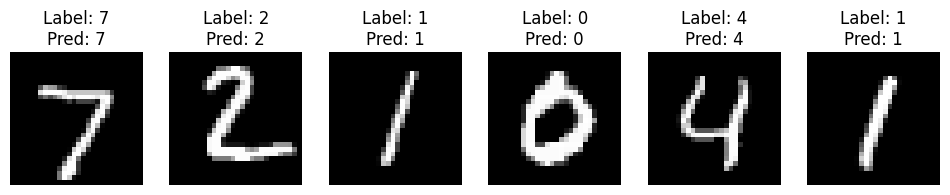

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. 数据加载与预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转为张量
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1, 1]
])

# 加载 MNIST 数据集
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# 2. 定义 CNN 模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 定义卷积层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)  # 输入1通道，输出32通道
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 输入32通道，输出64通道
        # 定义全连接层
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 展平后输入到全连接层
        self.fc2 = nn.Linear(128, 10)  # 10 个类别

    def forward(self, x):
        x = F.relu(self.conv1(x))  # 第一层卷积 + ReLU
        x = F.max_pool2d(x, 2)     # 最大池化
        x = F.relu(self.conv2(x))  # 第二层卷积 + ReLU
        x = F.max_pool2d(x, 2)     # 最大池化
        x = x.view(-1, 64 * 7 * 7) # 展平
        x = F.relu(self.fc1(x))    # 全连接层 + ReLU
        x = self.fc2(x)            # 最后一层输出
        return x

# 创建模型实例
model = SimpleCNN()

# 3. 定义损失函数与优化器
criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 4. 模型训练
num_epochs = 5
model.train()  # 设置模型为训练模式

for epoch in range(num_epochs):
    total_loss = 0
    for images, labels in train_loader:
        outputs = model(images)  # 前向传播
        loss = criterion(outputs, labels)  # 计算损失

        optimizer.zero_grad()  # 清空梯度
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

# 5. 模型测试
model.eval()  # 设置模型为评估模式
correct = 0
total = 0

with torch.no_grad():  # 关闭梯度计算
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# 6. 可视化测试结果
dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images)
_, predictions = torch.max(outputs, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 4))
for i in range(6):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}\nPred: {predictions[i]}")
    axes[i].axis('off')
plt.show()

Epoch [20/200], Loss: 0.0021
Epoch [40/200], Loss: 0.0003
Epoch [60/200], Loss: 0.0002
Epoch [80/200], Loss: 0.0002
Epoch [100/200], Loss: 0.0001
Epoch [120/200], Loss: 0.0001
Epoch [140/200], Loss: 0.0001
Epoch [160/200], Loss: 0.0001
Epoch [180/200], Loss: 0.0001
Epoch [200/200], Loss: 0.0001
Input sequence:  hello
Predicted sequence:  elloh


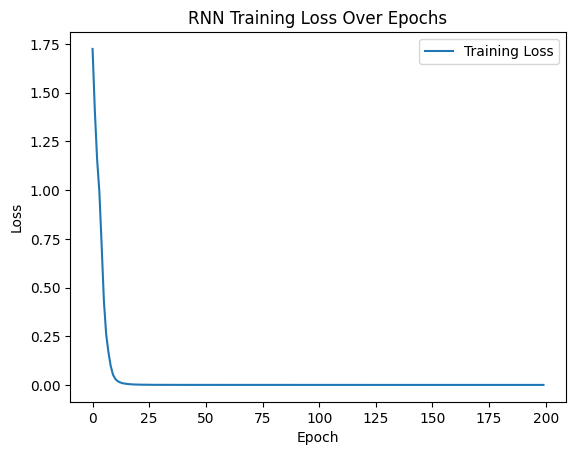

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 数据集：字符序列预测（Hello -> Elloh）
char_set = list("hello")
char_to_idx = {c: i for i, c in enumerate(char_set)}
idx_to_char = {i: c for i, c in enumerate(char_set)}

# 数据准备
input_str = "hello"
target_str = "elloh"
input_data = [char_to_idx[c] for c in input_str]
target_data = [char_to_idx[c] for c in target_str]

# 转换为独热编码
input_one_hot = np.eye(len(char_set))[input_data]

# 转换为 PyTorch Tensor
inputs = torch.tensor(input_one_hot, dtype=torch.float32)
targets = torch.tensor(target_data, dtype=torch.long)

# 模型超参数
input_size = len(char_set)
hidden_size = 8
output_size = len(char_set)
num_epochs = 200
learning_rate = 0.1

# 定义 RNN 模型
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)  # 应用全连接层
        return out, hidden

model = RNNModel(input_size, hidden_size, output_size)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 训练 RNN
losses = []
hidden = None  # 初始隐藏状态为 None
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # 前向传播
    outputs, hidden = model(inputs.unsqueeze(0), hidden)
    hidden = hidden.detach()  # 防止梯度爆炸

    # 计算损失
    loss = criterion(outputs.view(-1, output_size), targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

# 测试 RNN
with torch.no_grad():
    test_hidden = None
    test_output, _ = model(inputs.unsqueeze(0), test_hidden)
    predicted = torch.argmax(test_output, dim=2).squeeze().numpy()

    print("Input sequence: ", ''.join([idx_to_char[i] for i in input_data]))
    print("Predicted sequence: ", ''.join([idx_to_char[i] for i in predicted]))

# 可视化损失
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss Over Epochs")
plt.legend()
plt.show()

In [6]:
import torch
from torch.utils.data import Dataset

# 自定义数据集
class MyDataset(Dataset):
    def __init__(self, data, labels):
        # 数据初始化
        self.data = data
        self.labels = labels

    def __len__(self):
        # 返回数据集大小
        return len(self.data)

    def __getitem__(self, idx):
        # 按索引返回数据和标签
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

# 生成示例数据
data = torch.randn(100, 5)  # 100 个样本，每个样本有 5 个特征
labels = torch.randint(0, 2, (100,))  # 100 个标签，取值为 0 或 1

# 实例化数据集
dataset = MyDataset(data, labels)

# 测试数据集
print("数据集大小:", len(dataset))
print("第 0 个样本:", dataset[0])

数据集大小: 100
第 0 个样本: (tensor([ 0.3915, -0.9861,  1.0074, -1.0558,  1.0599]), tensor(1))


In [7]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# 自定义数据集
class MyDataset(Dataset):
    def __init__(self, data, labels):
        # 数据初始化
        self.data = data
        self.labels = labels

    def __len__(self):
        # 返回数据集大小
        return len(self.data)

    def __getitem__(self, idx):
        # 按索引返回数据和标签
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

# 生成示例数据
data = torch.randn(100, 5)  # 100 个样本，每个样本有 5 个特征
labels = torch.randint(0, 2, (100,))  # 100 个标签，取值为 0 或 1

# 实例化数据集
dataset = MyDataset(data, labels)
# 实例化 DataLoader
dataloader = DataLoader(dataset, batch_size=10, shuffle=True, num_workers=0)

# 遍历 DataLoader
for batch_idx, (batch_data, batch_labels) in enumerate(dataloader):
    print(f"批次 {batch_idx + 1}")
    print("数据:", batch_data)
    print("标签:", batch_labels)
    if batch_idx == 2:  # 仅显示前 3 个批次
        break

批次 1
数据: tensor([[ 0.0041,  0.0626, -0.9319, -1.1260, -1.0900],
        [-0.1106,  0.4622,  1.4995,  1.3817,  0.8852],
        [-1.4747,  1.4550, -1.1816, -1.8812, -0.6962],
        [ 0.3085,  0.8139, -1.0749,  1.3391, -1.4438],
        [-0.4456, -0.2291,  0.7454,  0.4216,  0.5743],
        [ 1.1711, -1.0342,  0.8762,  0.2386,  1.5177],
        [-0.0487,  0.3913, -0.6259, -1.4246, -0.6536],
        [-0.7583, -0.5846, -0.5778, -0.2045, -2.0428],
        [ 1.1934,  0.6323, -0.2482,  0.6907, -0.4131],
        [-1.5667,  0.9346, -1.0013,  1.5499, -0.7343]])
标签: tensor([1, 1, 1, 1, 1, 0, 1, 1, 1, 1])
批次 2
数据: tensor([[ 0.1211,  0.5176,  1.8183, -0.4793,  0.3645],
        [-0.1627,  1.4606,  1.0311,  0.3204,  0.0134],
        [ 2.3576,  0.9326,  1.0576, -0.6021, -0.3627],
        [-0.3416, -0.0037, -0.2099,  0.0366,  0.9800],
        [-2.0428, -0.1102, -0.4380, -0.5471,  0.6696],
        [ 0.2303,  0.1444, -0.4138,  0.4222, -0.7403],
        [-0.1900,  1.8590, -0.2957,  1.1365,  1.0650],
   

In [8]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为张量
    transforms.Normalize((0.5,), (0.5,))  # 标准化
])

# 加载训练数据集
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

# 使用 DataLoader 加载数据
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 查看一个批次的数据
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"批次图像大小: {images.shape}")  # 输出形状为 [batch_size, 1, 28, 28]
print(f"批次标签: {labels}")

批次图像大小: torch.Size([32, 1, 28, 28])
批次标签: tensor([8, 7, 4, 0, 0, 4, 6, 9, 5, 2, 5, 4, 3, 8, 7, 0, 3, 4, 3, 5, 6, 9, 2, 1,
        1, 2, 3, 7, 4, 4, 4, 9])


In [15]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# 自定义 CSV 数据集
class CSVDataset(Dataset):
    def __init__(self, file_path):
        # 读取 CSV 文件
        self.data = pd.read_csv(file_path)

    def __len__(self):
        # 返回数据集大小
        return len(self.data)

    def __getitem__(self, idx):
        # 使用 .iloc 明确基于位置索引
        row = self.data.iloc[idx]
        # 将特征和标签分开
        features = torch.tensor(row.iloc[:-1].to_numpy(), dtype=torch.float32)  # 特征
        label = torch.tensor(row.iloc[-1], dtype=torch.float32)  # 标签
        return features, label

# 实例化数据集和 DataLoader
dataset = CSVDataset(r"C:\Users\gsb\Desktop\runoob_pytorch_data.csv")
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# 遍历 DataLoader
for features, label in dataloader:
    print("特征:", features)
    print("标签:", label)
    break

特征: tensor([[-1.1000,  0.8000,  1.5000],
        [ 1.5000,  2.2000, -1.1000],
        [ 0.5000, -1.2000,  3.3000],
        [-0.3000,  0.8000,  1.2000]])
标签: tensor([1., 0., 1., 0.])


In [13]:
import pandas
print(pandas.__version__)

2.3.3


In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 定义转换
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 加载数据集
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# 使用 DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

# 查看转换后的数据
for images, labels in train_loader:
    print("图像张量大小:", images.size())  # [batch_size, 1, 128, 128]
    break

图像张量大小: torch.Size([32, 1, 128, 128])


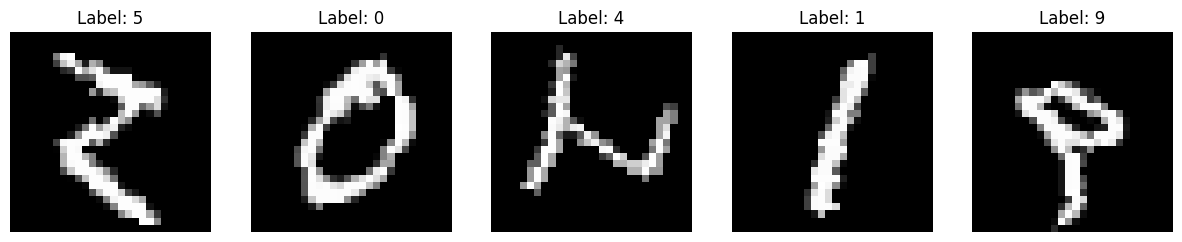

In [18]:
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import datasets, transforms


# 原始和增强后的图像可视化
transform_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

# 加载数据集
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_augment)

# 显示图像
def show_images(dataset):
    fig, axs = plt.subplots(1, 5, figsize=(15, 5))
    for i in range(5):
        image, label = dataset[i]
        axs[i].imshow(image.squeeze(0), cmap='gray')  # 将 (1, H, W) 转为 (H, W)
        axs[i].set_title(f"Label: {label}")
        axs[i].axis('off')
    plt.show()

show_images(dataset)

In [1]:
import torch
import time

device = torch.device("cuda")
n = 5000

# CPU 矩阵乘法
a_cpu = torch.randn(n, n)
b_cpu = torch.randn(n, n)
start = time.time()
c_cpu = torch.matmul(a_cpu, b_cpu)
print(f"CPU 耗时: {time.time() - start:.3f}s")

# GPU 矩阵乘法
a_gpu = a_cpu.to(device)
b_gpu = b_cpu.to(device)
torch.cuda.synchronize()    # 确保数据已传输完毕再开始计时
start = time.time()
c_gpu = torch.matmul(a_gpu, b_gpu)
torch.cuda.synchronize()    # 等待 GPU 执行完毕再停止计时
print(f"GPU 耗时: {time.time() - start:.3f}s")

CPU 耗时: 1.179s
GPU 耗时: 0.078s
